# 01 — EDA, PCA & K-Means

Στόχος αυτού του notebook:

1. Να κάνουμε βασικό EDA στο dataset.
2. Να ελέγξουμε missing values, outliers και class imbalance.
3. Να φτιάξουμε απλά clinical features που βοηθούν στην ερμηνεία.
4. Να κρατήσουμε το βασικό PCA γράφημα, ώστε να δούμε αν οι ομάδες ασθενών έχουν οπτικό διαχωρισμό.
5. Να χρησιμοποιήσουμε K-Means για να δούμε αν υπάρχουν φυσικά patient subgroups.
6. Να κρατήσουμε μόνο καθαρά και χρήσιμα plots για παρουσίαση.

> Σημείωση: Αφαιρέθηκαν τα TOST / non-inferiority sections, γιατί μπέρδευαν τη ροή και δεν είναι απαραίτητα για αυτό το EDA + PCA + clustering notebook.


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


## 1. Load data

In [2]:
DATA_PATHS = [
    Path("main_augmented_full.csv"),
    Path("main.csv"),
    Path("/mnt/data/main_augmented_full.csv"),
]

for path in DATA_PATHS:
    if path.exists():
        DATA_PATH = path
        break
else:
    raise FileNotFoundError("Δεν βρέθηκε το dataset. Βάλε το main_augmented_full.csv στον ίδιο φάκελο με το notebook.")

df = pd.read_csv(DATA_PATH)

print("Loaded file:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())
display(df.info())


Loaded file: main_augmented_full.csv
Shape: (3037, 18)


,subject_id,hadm_id,gender,age,icd9_code,short_title,long_title,liver_group,ast,alt,ast_alt_ratio,bilirubin,albumin,platelets,inr,creatinine,glucose,fib4_score
0,52,190797,M,39,5712.0,Alcohol cirrhosis liver,Alcoholic cirrhosis of liver,ALCOHOLIC_LIVER_DISEASE,58.0,30.0,1.933333,15.7,3.0,47.0,2.7,139.0,203.0,8.786868262955219
1,117,164853,F,50,5712.0,Alcohol cirrhosis liver,Alcoholic cirrhosis of liver,ALCOHOLIC_LIVER_DISEASE,9295.0,2442.0,3.806306,54.0,1.7,24.0,3.9,165.0,244.0,391.8639635890366
2,252,190159,M,55,5712.0,Alcohol cirrhosis liver,Alcoholic cirrhosis of liver,ALCOHOLIC_LIVER_DISEASE,78.0,25.0,3.120000,2.2,1.9,61.0,2.4,72.0,141.0,14.065573770491802
3,252,193470,M,55,5712.0,Alcohol cirrhosis liver,Alcoholic cirrhosis of liver,ALCOHOLIC_LIVER_DISEASE,33.0,11.0,3.000000,1.6,2.6,91.0,1.5,1.0,110.0,6.01366033416089
4,285,165312,M,45,5711.0,Ac alcoholic hepatitis,Acute alcoholic hepatitis,ALCOHOLIC_LIVER_DISEASE,287.0,167.0,1.718563,0.8,1.9,105.0,1.3,89.0,212.0,9.518025760169882


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3037 entries, 0 to 3036
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject_id     3037 non-null   object 
 1   hadm_id        3037 non-null   object 
 2   gender         3037 non-null   object 
 3   age            3037 non-null   int64  
 4   icd9_code      3037 non-null   float64
 5   short_title    3037 non-null   object 
 6   long_title     3037 non-null   object 
 7   liver_group    3037 non-null   object 
 8   ast            3037 non-null   float64
 9   alt            3037 non-null   float64
 10  ast_alt_ratio  3037 non-null   float64
 11  bilirubin      3037 non-null   float64
 12  albumin        3037 non-null   float64
 13  platelets      3037 non-null   float64
 14  inr            3037 non-null   float64
 15  creatinine     3037 non-null   float64
 16  glucose        3037 non-null   float64
 17  fib4_score     3037 non-null   object 
dtypes: float

None

## 2. Basic data quality checks

In [3]:
# Missing values percentage
missing_pct = (
    df.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)
missing_pct.columns = ["column", "missing_%"]

display(missing_pct.head(30))

,column,missing_%
0,subject_id,0.0
1,hadm_id,0.0
2,gender,0.0
3,age,0.0
4,icd9_code,0.0
5,short_title,0.0
6,long_title,0.0
7,liver_group,0.0
8,ast,0.0
9,alt,0.0


## 3. Clean labs and basic preprocessing

In [4]:
# Βασικά lab columns που χρησιμοποιούμε στο EDA.
# Αν κάποιο column λείπει από το dataset, το αγνοούμε αυτόματα.
candidate_lab_columns = [
    "alt", "ast", "creatinine", "platelets", "glucose",
    "bilirubin", "inr", "fib4_score", "ast_alt_ratio"
]

lab_columns = [c for c in candidate_lab_columns if c in df.columns]
print("Available lab columns:", lab_columns)

# Median imputation για labs, επειδή οι ιατρικές τιμές συνήθως είναι skewed.
for col in lab_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

# Clipping στο 1ο και 99ο percentile για να μη μας χαλάνε τα ακραία outliers.
for col in lab_columns:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

# Drop duplicate admissions, αν υπάρχει hadm_id.
if "hadm_id" in df.columns:
    df = df.drop_duplicates(subset=["hadm_id"])

print("Shape after cleaning:", df.shape)

Available lab columns: ['alt', 'ast', 'creatinine', 'platelets', 'glucose', 'bilirubin', 'inr', 'fib4_score', 'ast_alt_ratio']
Shape after cleaning: (2707, 18)


## 4. Target / class distribution

,count,percentage_%
liver_group,,
ALCOHOLIC_LIVER_DISEASE,1284,47.43
CIRRHOSIS,1085,40.08
MASH_NAFLD,212,7.83
CHRONIC_HEPATITIS,72,2.66
BILIARY_CIRRHOSIS,49,1.81
CHRONIC_LIVER_DISEASE_UNSPECIFIED,5,0.18


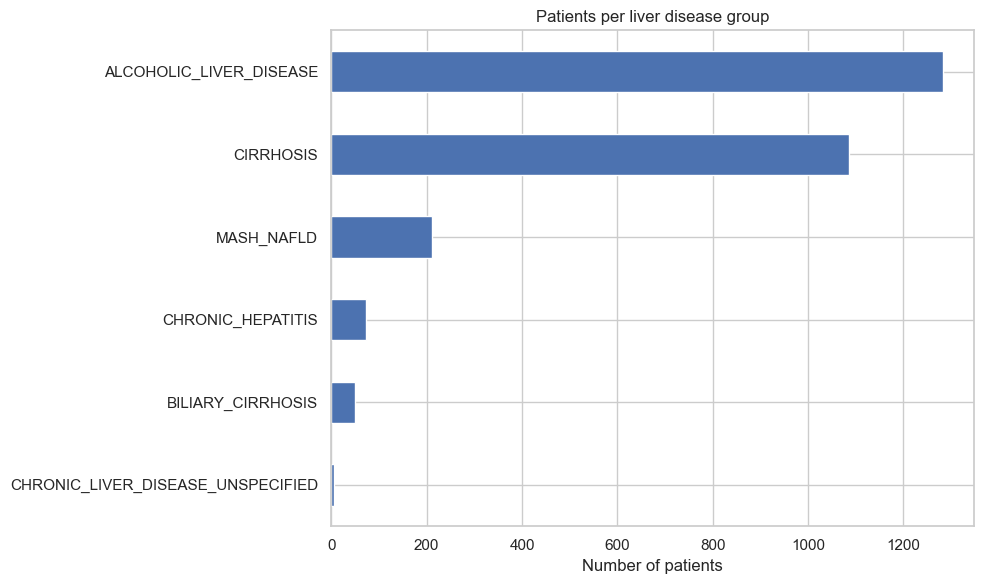

In [5]:
target_col = "liver_group"

class_counts = df[target_col].value_counts()
class_pct = df[target_col].value_counts(normalize=True).mul(100).round(2)

display(pd.DataFrame({"count": class_counts, "percentage_%": class_pct}))

plt.figure(figsize=(10, 6))
class_counts.sort_values().plot(kind="barh")
plt.title("Patients per liver disease group")
plt.xlabel("Number of patients")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 5. Demographics and lab distributions

Εδώ βλέπουμε βασική εικόνα του πληθυσμού και των εργαστηριακών τιμών.

Σκοπός δεν είναι να βγάλουμε τελικό συμπέρασμα μόνο από τα histograms, αλλά να δούμε αν υπάρχουν skewed distributions, ακραίες τιμές ή patterns που εξηγούν γιατί χρειάζεται προσεκτικό preprocessing.


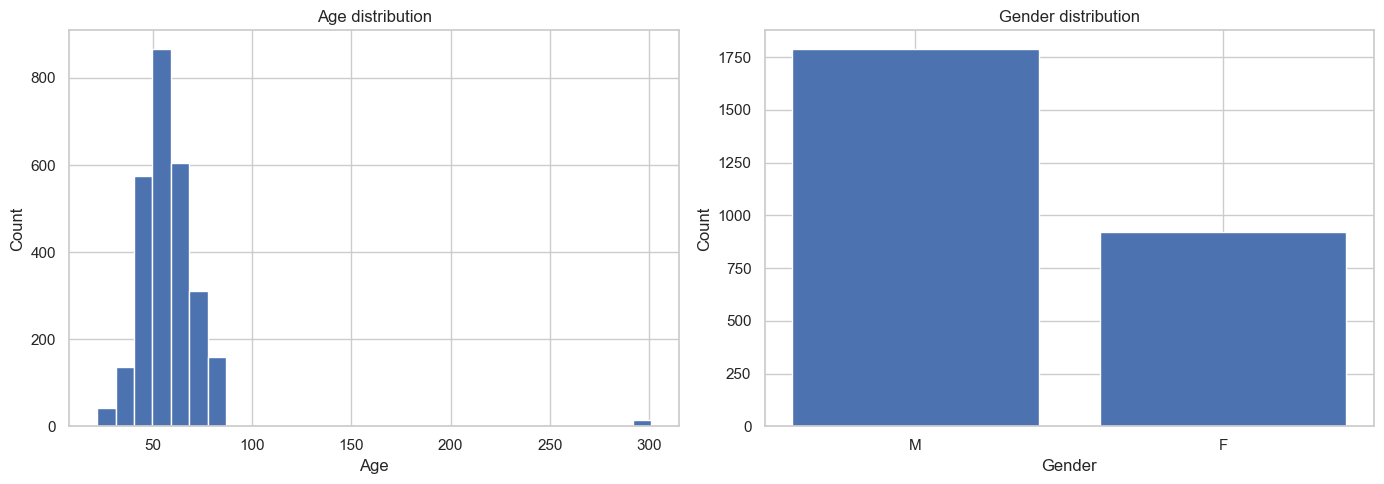

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "age" in df.columns:
    axes[0].hist(df["age"].dropna(), bins=30)
    axes[0].set_title("Age distribution")
    axes[0].set_xlabel("Age")
    axes[0].set_ylabel("Count")
else:
    axes[0].axis("off")

if "gender" in df.columns:
    gender_counts = df["gender"].value_counts(dropna=False)
    axes[1].bar(gender_counts.index.astype(str), gender_counts.values)
    axes[1].set_title("Gender distribution")
    axes[1].set_xlabel("Gender")
    axes[1].set_ylabel("Count")
else:
    axes[1].axis("off")

plt.tight_layout()
plt.show()


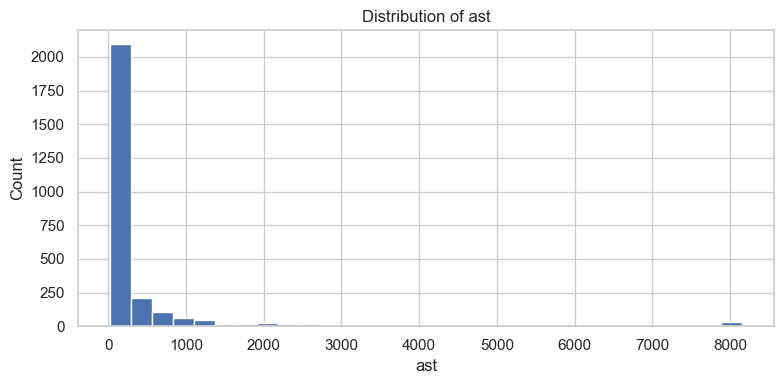

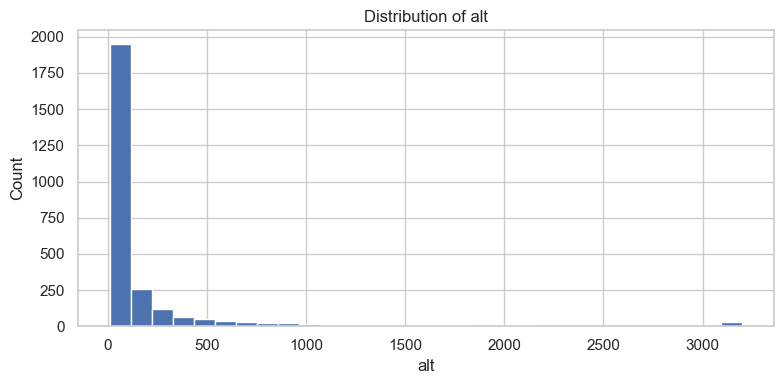

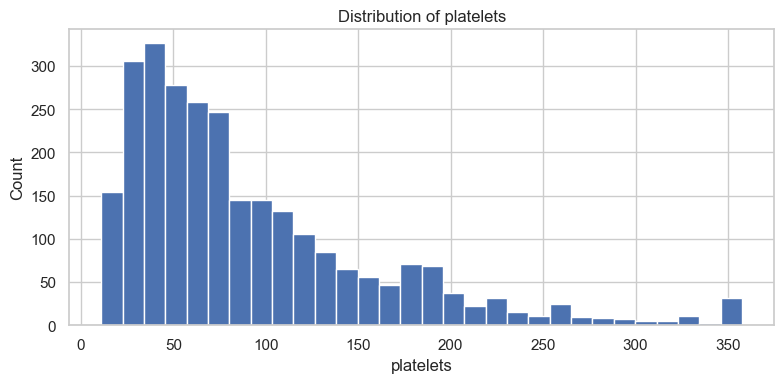

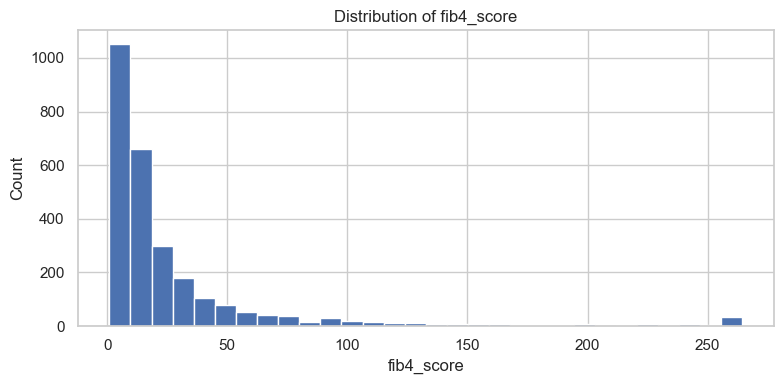

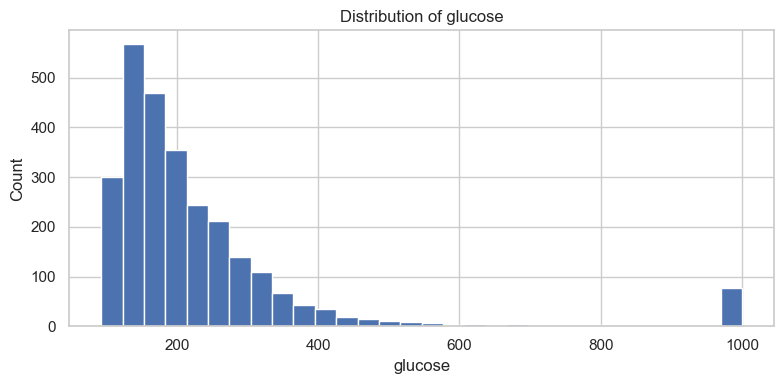

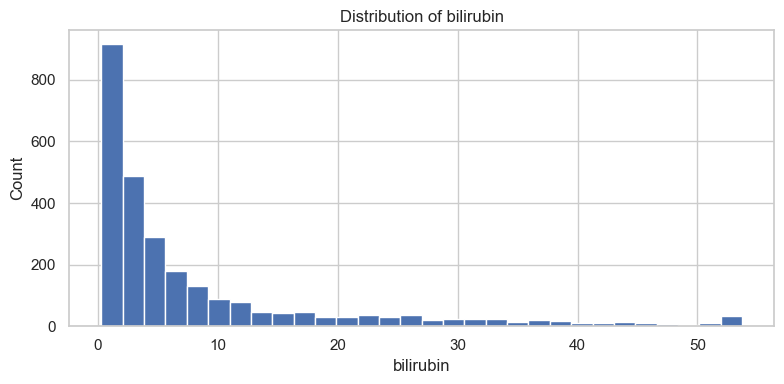

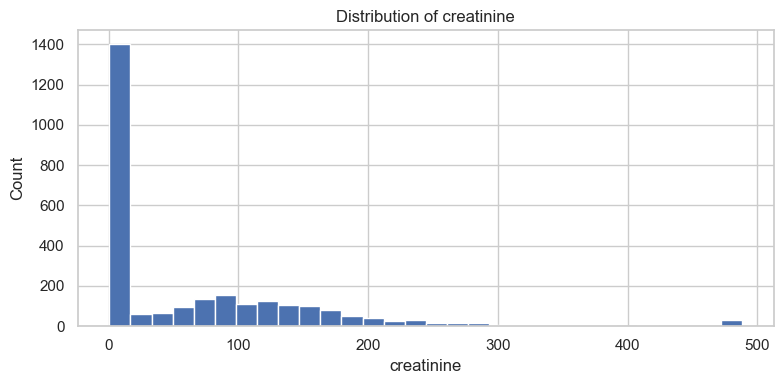

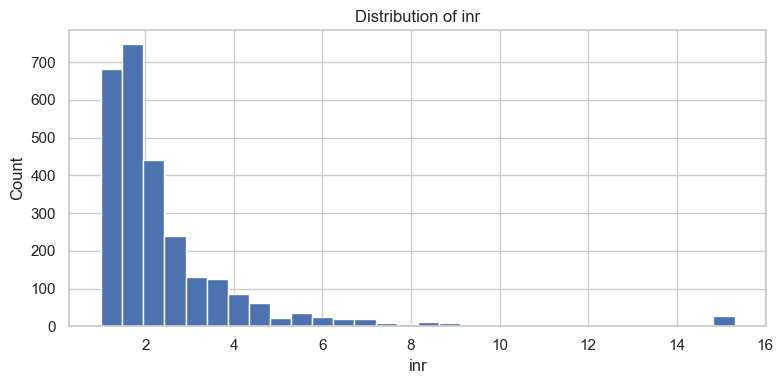

In [7]:
# Distributions βασικών labs.
plot_cols = [c for c in ["ast", "alt", "platelets", "fib4_score", "glucose", "bilirubin", "creatinine", "inr"] if c in df.columns]

for col in plot_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


## 6. Clinical feature engineering

Φτιάχνουμε απλά παράγωγα features που έχουν κλινική ερμηνεία.

Παραδείγματα:

- **APRI score**: συνδυάζει AST και platelets.
- **Metabolic risk**: απλό proxy για μεγαλύτερη ηλικία και αυξημένη γλυκόζη.
- **Severity proxy**: συνδυάζει bilirubin και INR.
- **Thrombocytopenia flag**: δείχνει χαμηλά platelets.

Αυτά βοηθούν και στο PCA και στο K-Means, γιατί δίνουν πιο ερμηνεύσιμη πληροφορία από τα raw labs μόνο.


In [8]:
# APRI = (AST / ULN_AST) / Platelets * 100
# Χρησιμοποιούμε ULN_AST=40 ως απλοποιημένη υπόθεση για το hackathon.
if {"ast", "platelets"}.issubset(df.columns):
    df["apri_score"] = (df["ast"] / 40.0) / df["platelets"] * 100

if {"glucose", "age"}.issubset(df.columns):
    df["metabolic_risk"] = ((df["glucose"] > 100) & (df["age"] > 50)).astype(int)

if {"bilirubin", "inr"}.issubset(df.columns):
    df["severity_proxy"] = df["bilirubin"] * df["inr"]

if "platelets" in df.columns:
    df["has_thrombocytopenia"] = (df["platelets"] < 150).astype(int)

if "age" in df.columns:
    df["is_senior"] = (df["age"] >= 60).astype(int)

feature_cols = [
    "ast", "alt", "ast_alt_ratio", "platelets", "fib4_score",
    "glucose", "bilirubin", "age", "inr", "creatinine",
    "apri_score", "metabolic_risk", "severity_proxy",
    "has_thrombocytopenia", "is_senior"
]

feature_cols = [c for c in feature_cols if c in df.columns]

# Μετατρέπουμε όλα τα feature columns σε numeric, ώστε PCA/K-Means να μη σπάνε από string values.
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    df[col] = df[col].fillna(df[col].median())

print("Final EDA features:", feature_cols)
display(df[feature_cols].describe().T)


Final EDA features: ['ast', 'alt', 'ast_alt_ratio', 'platelets', 'fib4_score', 'glucose', 'bilirubin', 'age', 'inr', 'creatinine', 'apri_score', 'metabolic_risk', 'severity_proxy', 'has_thrombocytopenia', 'is_senior']


,count,mean,std,min,25%,50%,75%,max
ast,2707.0,454.924418,1180.654813,17.000000,56.000000,105.000000,254.500000,8158.800000
alt,2707.0,216.962409,489.524707,9.000000,30.000000,53.000000,137.000000,3200.560000
ast_alt_ratio,2707.0,2.177443,1.241228,0.572272,1.384615,1.878788,2.590909,7.697143
platelets,2707.0,90.981411,68.581881,11.000000,42.000000,70.000000,119.000000,357.560000
fib4_score,2707.0,28.015557,44.340573,0.927796,6.183245,13.041239,28.345969,264.439759
glucose,2707.0,231.804581,165.546839,93.000000,142.000000,184.000000,254.500000,1000.000000
bilirubin,2707.0,8.491217,11.508268,0.300000,1.400000,3.600000,9.650000,53.712000
age,2707.0,58.204655,21.067103,22.000000,49.000000,56.000000,65.000000,301.000000
inr,2707.0,2.502448,2.001316,1.000000,1.400000,1.900000,2.700000,15.304000
creatinine,2707.0,67.268114,92.966670,0.500000,1.000000,7.300000,116.000000,488.328000


## 7. Correlation heatmap

Αυτό το γράφημα δείχνει ποια κλινικά χαρακτηριστικά κινούνται μαζί.

- Τιμές κοντά στο **+1** σημαίνουν ότι δύο features αυξάνονται μαζί.
- Τιμές κοντά στο **-1** σημαίνουν ότι όταν το ένα αυξάνεται, το άλλο τείνει να μειώνεται.
- Είναι χρήσιμο πριν από PCA/K-Means, γιατί μας δείχνει αν υπάρχουν features που μεταφέρουν παρόμοια πληροφορία.


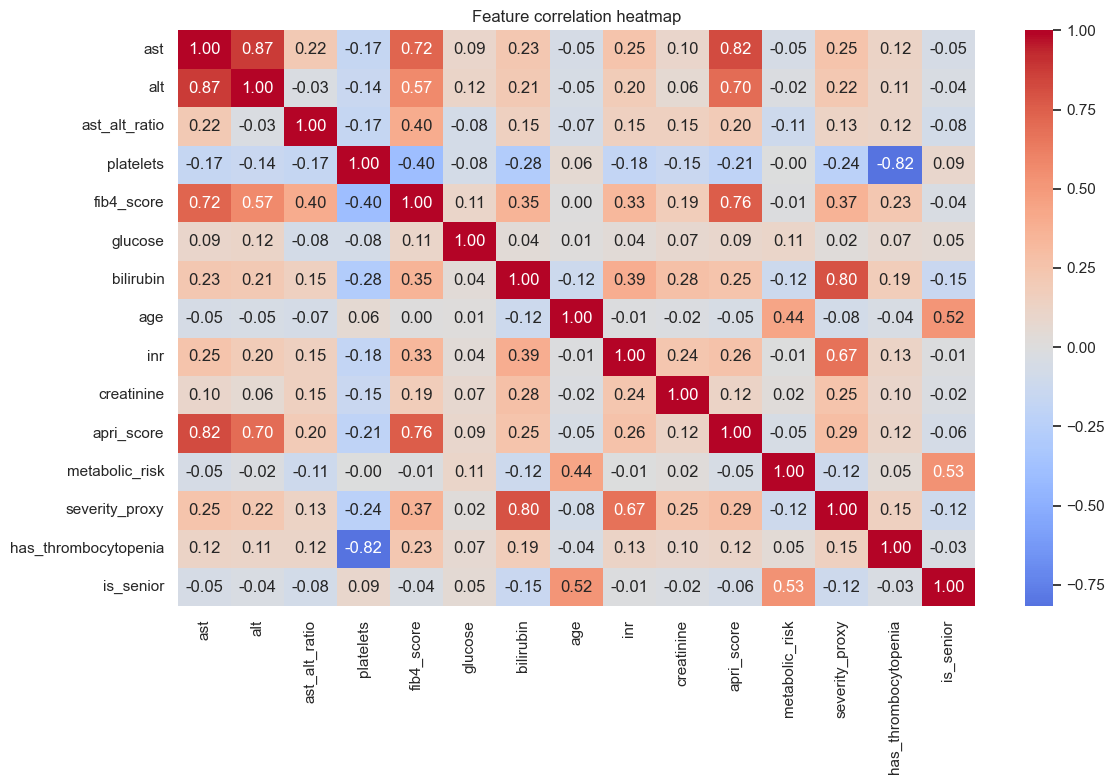

In [9]:
corr = df[feature_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

## 8. PCA explained variance

Εδώ βλέπουμε πόση πληροφορία κρατάνε οι principal components.

Το PCA μετατρέπει πολλά correlated features σε λίγες νέες μεταβλητές. Αν οι πρώτες 2–3 components κρατάνε αρκετή variance, τότε ένα 2D PCA plot μπορεί να δώσει χρήσιμη οπτική εικόνα για τη δομή των ασθενών.


## 8. PCA 2D scatter: true liver groups

Αυτό είναι το βασικό PCA γράφημα που κρατάμε.

Κάθε τελεία είναι ένας ασθενής. Οι άξονες PCA_1 και PCA_2 είναι συμπυκνωμένες εκδοχές των αρχικών clinical features. Αν οι χρωματισμένες ομάδες σχηματίζουν σχετικά ξεχωριστές περιοχές, τότε υπάρχει ένδειξη ότι τα κλινικά features περιέχουν πληροφορία που σχετίζεται με το `liver_group`.

Δεν περιμένουμε τέλειο διαχωρισμό, γιατί τα πραγματικά ιατρικά δεδομένα έχουν overlap.


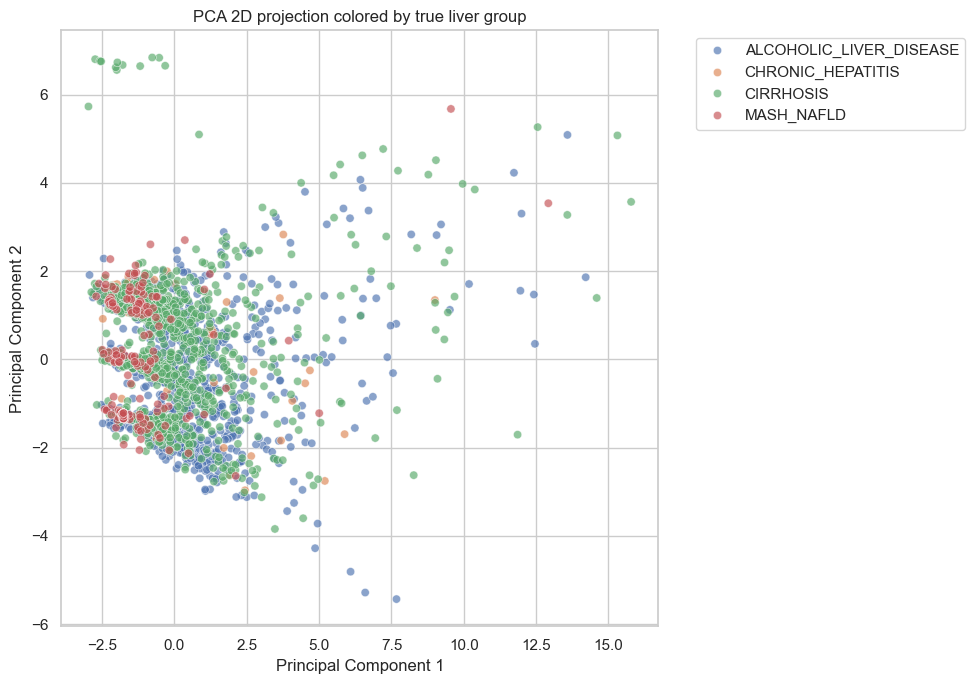

In [11]:
# Για καθαρή οπτικοποίηση κρατάμε τις 4 μεγαλύτερες κλάσεις.
top_classes = df[target_col].value_counts().head(4).index.tolist()
df_pca = df[df[target_col].isin(top_classes)].copy()

X_pca_input = df_pca[feature_cols].replace([np.inf, -np.inf], np.nan)
X_pca_input = X_pca_input.fillna(X_pca_input.median(numeric_only=True))

X_pca_scaled = StandardScaler().fit_transform(X_pca_input)

pca_2d = PCA(n_components=2)
components = pca_2d.fit_transform(X_pca_scaled)

df_pca["PCA_1"] = components[:, 0]
df_pca["PCA_2"] = components[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_pca,
    x="PCA_1",
    y="PCA_2",
    hue=target_col,
    alpha=0.65
)
plt.title("PCA 2D projection colored by true liver group")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 9. K-Means πάνω στο PCA space

Εδώ συγκρίνουμε δύο πράγματα:

1. Αριστερά: τις πραγματικές κλινικές ομάδες (`liver_group`).
2. Δεξιά: τα clusters που βρήκε το K-Means χωρίς να γνωρίζει τη διάγνωση.

Αν τα clusters μοιάζουν με τις πραγματικές ομάδες, τότε τα features έχουν δομή που συμφωνεί με την κλινική ταξινόμηση. Αν όχι, πάλι είναι χρήσιμο: μπορεί να δείχνει υποομάδες ασθενών που δεν ταυτίζονται απόλυτα με τις labels.


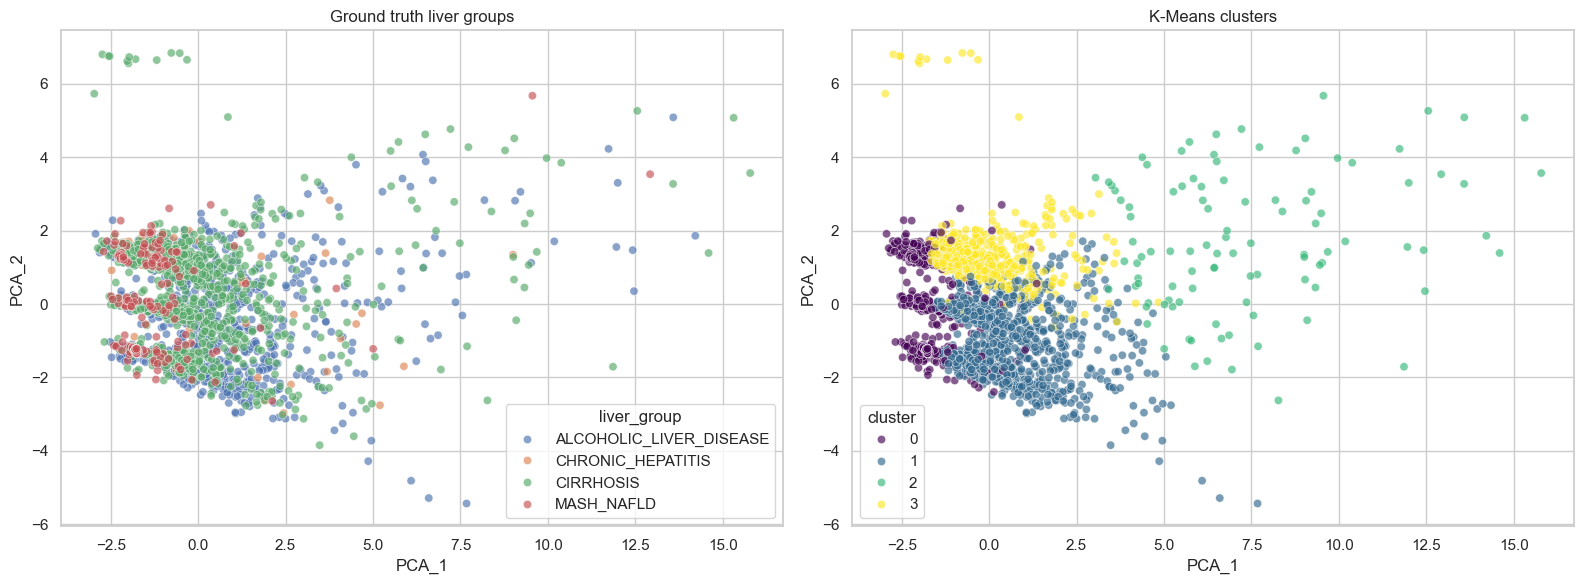

liver_group,ALCOHOLIC_LIVER_DISEASE,CHRONIC_HEPATITIS,CIRRHOSIS,MASH_NAFLD
cluster,,,,
0,0.360,0.027,0.321,0.292
1,0.598,0.017,0.354,0.030
2,0.441,0.039,0.490,0.029
3,0.379,0.041,0.531,0.049


In [14]:
# Επιλέγουμε K=4 για να το συγκρίνουμε με τις 4 μεγαλύτερες κλινικές ομάδες.
best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=5, max_iter=100)
df_pca["cluster"] = kmeans.fit_predict(X_pca_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=df_pca,
    x="PCA_1",
    y="PCA_2",
    hue=target_col,
    alpha=0.65,
    ax=axes[0]
)
axes[0].set_title("Ground truth liver groups")

sns.scatterplot(
    data=df_pca,
    x="PCA_1",
    y="PCA_2",
    hue="cluster",
    palette="viridis",
    alpha=0.65,
    ax=axes[1]
)
axes[1].set_title("K-Means clusters")

plt.tight_layout()
plt.show()

cluster_vs_group = pd.crosstab(df_pca["cluster"], df_pca[target_col], normalize="index").round(3)
display(cluster_vs_group)


## 10. Cluster profiling

Αφού βρούμε clusters, θέλουμε να καταλάβουμε τι σημαίνει κάθε cluster κλινικά.

Για αυτό βλέπουμε median τιμές και boxplots ανά cluster. Έτσι μπορούμε να πούμε, για παράδειγμα, αν ένα cluster έχει υψηλότερο FIB-4/APRI, χαμηλότερα platelets ή μεγαλύτερη severity proxy.


cluster,0,1,2,3
ast,61.500000,128.000000,5482.000000,83.000000
alt,32.000000,60.000000,1797.500000,43.000000
ast_alt_ratio,1.586207,2.000000,2.798465,1.804878
platelets,194.000000,57.000000,35.000000,69.000000
fib4_score,3.228235,15.563321,192.141398,13.484076
glucose,159.000000,180.000000,253.500000,202.000000
bilirubin,0.900000,5.100000,18.500000,3.100000
age,57.000000,51.000000,53.000000,67.000000
inr,1.400000,2.000000,4.050000,1.900000
creatinine,1.300000,11.500000,100.500000,8.600000


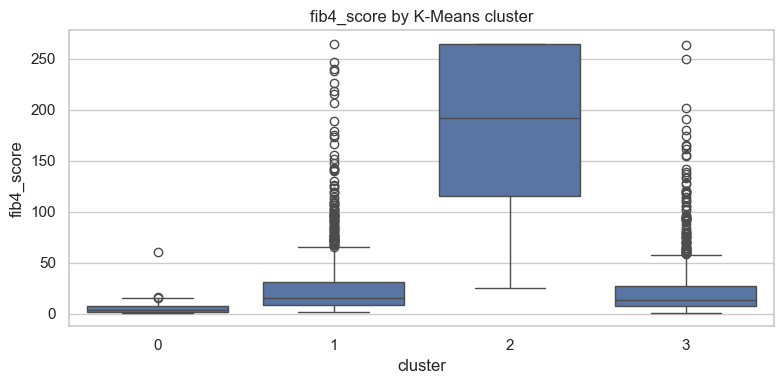

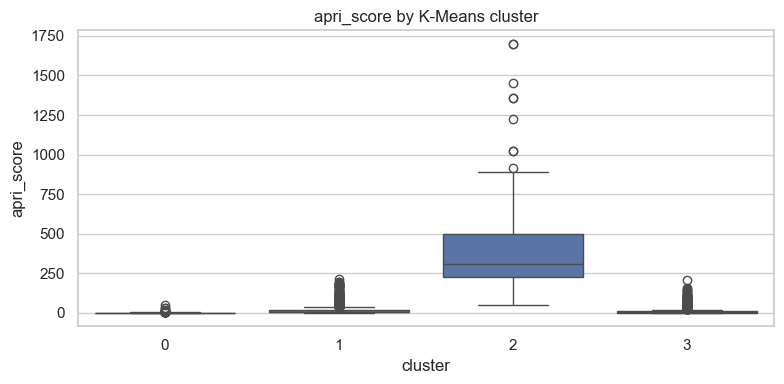

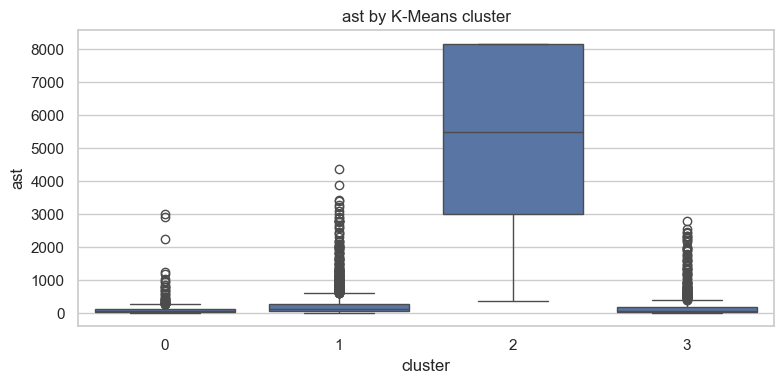

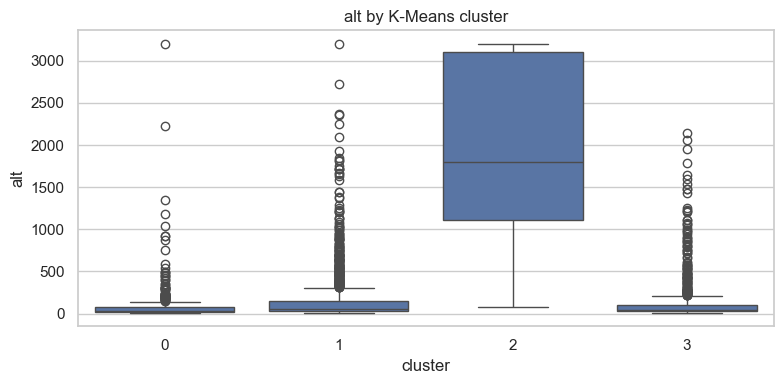

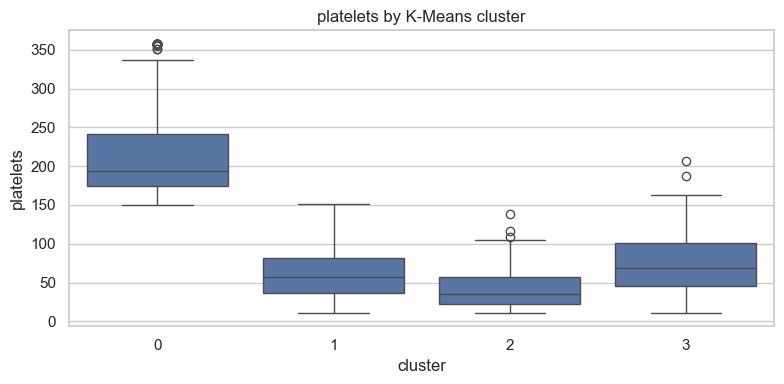

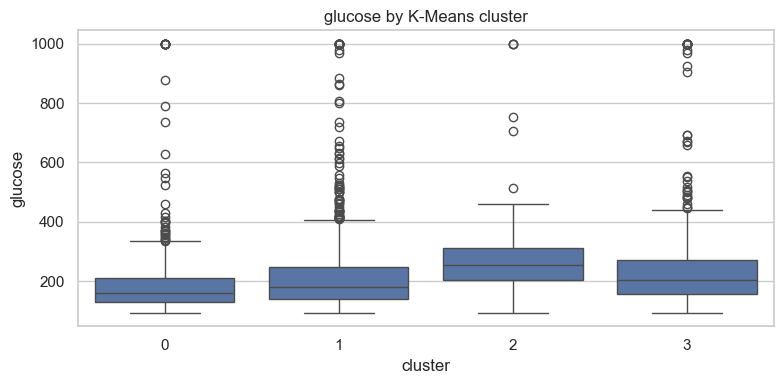

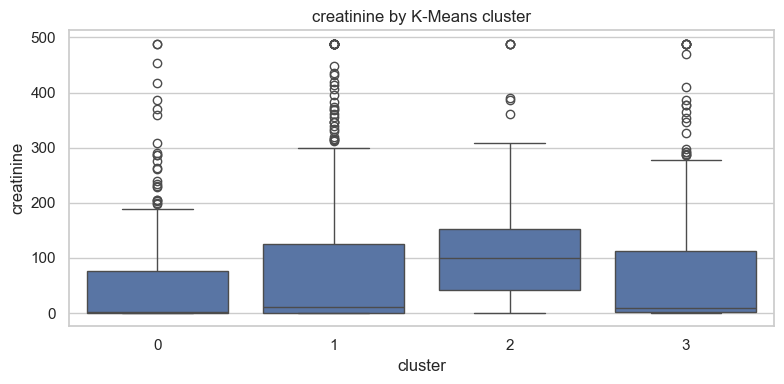

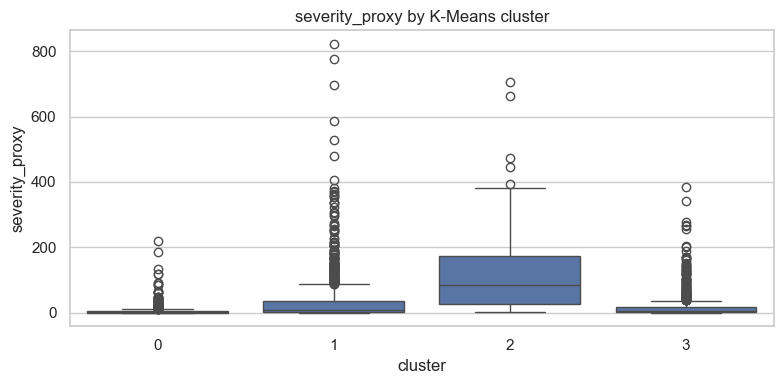

In [15]:
cluster_profile = df_pca.groupby("cluster")[feature_cols].median().T
display(cluster_profile)

# Κρατάμε λίγα σημαντικά features για readable boxplots.
profile_features = [c for c in ["fib4_score", "apri_score", "ast", "alt", "platelets", "glucose", "creatinine", "severity_proxy"] if c in df_pca.columns]

for col in profile_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_pca, x="cluster", y=col)
    plt.title(f"{col} by K-Means cluster")
    plt.tight_layout()
    plt.show()